<a href="https://colab.research.google.com/github/SanOsei/michigan-cardiovascular-mortality-prediction/blob/main/Heart_Python_file.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ANALYSIS AND PREDICTION OF CARDIOVASCULAR DISEASE MORTALITY RATES IN MICHIGAN


In [24]:
# Loading the necessary Libraries

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.ticker as ticker
import numpy as np
import warnings
warnings.filterwarnings("ignore")

Impoorting the Cardiovascular disease dataset from the : U.S. Department of Health & Human Services

In [26]:
Df = pd.read_csv(" https://data.cdc.gov/api/views/7b9s-s8ck/rows.csv?accessType=DOWNLOAD")
Df.head(5)

,Year,LocationAbbr,LocationDesc,GeographicLevel,DataSource,Class,Topic,Data_Value,Data_Value_Unit,Data_Value_Type,...,Data_Value_Footnote,Confidence_limit_Low,Confidence_limit_High,StratificationCategory1,Stratification1,StratificationCategory2,Stratification2,StratificationCategory3,Stratification3,LocationID
0,1999,AL,Autauga,County,NVSS,Cardiovascular Diseases,All heart disease,NaN,"per 100,000","Age-Standardized, Spatiotemporally Smoothed Rate",...,Value suppressed,NaN,NaN,Age group,Ages 35-64 years,Race,American Indian/Alaska Native,Sex,Overall,1001
1,2013,AL,Autauga,County,NVSS,Cardiovascular Diseases,All heart disease,NaN,"per 100,000","Age-Standardized, Spatiotemporally Smoothed Rate",...,Value suppressed,NaN,NaN,Age group,Ages 35-64 years,Race,American Indian/Alaska Native,Sex,Overall,1001
2,2014,AL,Autauga,County,NVSS,Cardiovascular Diseases,All heart disease,NaN,"per 100,000","Age-Standardized, Spatiotemporally Smoothed Rate",...,Value suppressed,NaN,NaN,Age group,Ages 35-64 years,Race,American Indian/Alaska Native,Sex,Overall,1001
3,2005,AL,Autauga,County,NVSS,Cardiovascular Diseases,All heart disease,NaN,"per 100,000","Age-Standardized, Spatiotemporally Smoothed Rate",...,Value suppressed,NaN,NaN,Age group,Ages 35-64 years,Race,American Indian/Alaska Native,Sex,Overall,1001
4,2012,AL,Autauga,County,NVSS,Cardiovascular Diseases,All heart disease,NaN,"per 100,000","Age-Standardized, Spatiotemporally Smoothed Rate",...,Value suppressed,NaN,NaN,Age group,Ages 35-64 years,Race,American Indian/Alaska Native,Sex,Overall,1001


Familiarizing Ourselves with the Dataset

In [27]:
# Finding the shape to know the numbe of rows and columns in our datasets
Df.shape

(5770240, 21)

In [28]:
# Dropping irrelevant Columns
Df.drop(columns=['GeographicLevel','DataSource','Class','Data_Value_Unit','Data_Value_Footnote','Data_Value_Footnote_Symbol','LocationID','StratificationCategory1','StratificationCategory2','StratificationCategory3'],inplace=True)


In [29]:
# Pick recent ten years from 2009 to 2019
recent_years = [2009,2010,2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
Df_recent = Df[Df['Year'].isin(recent_years)]
# df_recent.to_csv('recent_cardio_data.csv', index=False)
Df_recent

,Year,LocationAbbr,LocationDesc,Topic,Data_Value,Data_Value_Type,Confidence_limit_Low,Confidence_limit_High,Stratification1,Stratification2,Stratification3
1,2013,AL,Autauga,All heart disease,NaN,"Age-Standardized, Spatiotemporally Smoothed Rate",NaN,NaN,Ages 35-64 years,American Indian/Alaska Native,Overall
2,2014,AL,Autauga,All heart disease,NaN,"Age-Standardized, Spatiotemporally Smoothed Rate",NaN,NaN,Ages 35-64 years,American Indian/Alaska Native,Overall
4,2012,AL,Autauga,All heart disease,NaN,"Age-Standardized, Spatiotemporally Smoothed Rate",NaN,NaN,Ages 35-64 years,American Indian/Alaska Native,Overall
5,2010,AL,Autauga,All heart disease,NaN,"Age-Standardized, Spatiotemporally Smoothed Rate",NaN,NaN,Ages 35-64 years,American Indian/Alaska Native,Overall
6,2009,AL,Autauga,All heart disease,NaN,"Age-Standardized, Spatiotemporally Smoothed Rate",NaN,NaN,Ages 35-64 years,American Indian/Alaska Native,Overall
...,...,...,...,...,...,...,...,...,...,...,...
5210106,2018,WI,Taylor,All heart disease,NaN,"Age-Standardized, Spatiotemporally Smoothed Rate",NaN,NaN,Ages 35-64 years,Asian/Pacific Islander,Overall
5210107,2017,WI,Taylor,All heart disease,NaN,"Age-Standardized, Spatiotemporally Smoothed Rate",NaN,NaN,Ages 35-64 years,Asian/Pacific Islander,Overall
5210108,2009,WI,Taylor,All heart disease,NaN,"Age-Standardized, Spatiotemporally Smoothed Rate",NaN,NaN,Ages 35-64 years,Asian/Pacific Islander,Overall
5210109,2011,WI,Taylor,All heart disease,NaN,"Age-Standardized, Spatiotemporally Smoothed Rate",NaN,NaN,Ages 35-64 years,Asian/Pacific Islander,Overall


In [30]:
Df_recent.isnull().sum()  # Counts missing values per column

,0
Year,0
LocationAbbr,0
LocationDesc,0
Topic,0
Data_Value,1117497
Data_Value_Type,0
Confidence_limit_Low,1117497
Confidence_limit_High,1117497
Stratification1,0
Stratification2,0


In [31]:
# Null value imputations using then mean
Df_recent['Data_Value'] = Df_recent['Data_Value'].fillna(Df_recent['Data_Value'].mean())
Df_recent['Confidence_limit_Low'] = Df_recent['Confidence_limit_Low'].fillna(Df_recent['Confidence_limit_Low'].mean())
Df_recent['Confidence_limit_High'] = Df_recent['Confidence_limit_High'].fillna(Df_recent['Confidence_limit_High'].mean())
Df_recent.isnull().sum()

,0
Year,0
LocationAbbr,0
LocationDesc,0
Topic,0
Data_Value,0
Data_Value_Type,0
Confidence_limit_Low,0
Confidence_limit_High,0
Stratification1,0
Stratification2,0


In [32]:
# Checking for Duplicates
Df_recent.duplicated().sum()

np.int64(825)

In [33]:
# Removing Duplicates
Df_recent.drop_duplicates(inplace=True)

In [34]:
Df_recent.duplicated().sum()

np.int64(0)

Converting Year from a string to date time

In [35]:
Df_recent['Year'] = pd.to_datetime(Df_recent['Year'], format='%Y')
Df_recent['Year'] = Df_recent['Year'].dt.year
Df_recent

,Year,LocationAbbr,LocationDesc,Topic,Data_Value,Data_Value_Type,Confidence_limit_Low,Confidence_limit_High,Stratification1,Stratification2,Stratification3
1,2013,AL,Autauga,All heart disease,425.405555,"Age-Standardized, Spatiotemporally Smoothed Rate",372.852861,486.487282,Ages 35-64 years,American Indian/Alaska Native,Overall
2,2014,AL,Autauga,All heart disease,425.405555,"Age-Standardized, Spatiotemporally Smoothed Rate",372.852861,486.487282,Ages 35-64 years,American Indian/Alaska Native,Overall
4,2012,AL,Autauga,All heart disease,425.405555,"Age-Standardized, Spatiotemporally Smoothed Rate",372.852861,486.487282,Ages 35-64 years,American Indian/Alaska Native,Overall
5,2010,AL,Autauga,All heart disease,425.405555,"Age-Standardized, Spatiotemporally Smoothed Rate",372.852861,486.487282,Ages 35-64 years,American Indian/Alaska Native,Overall
6,2009,AL,Autauga,All heart disease,425.405555,"Age-Standardized, Spatiotemporally Smoothed Rate",372.852861,486.487282,Ages 35-64 years,American Indian/Alaska Native,Overall
...,...,...,...,...,...,...,...,...,...,...,...
5210106,2018,WI,Taylor,All heart disease,425.405555,"Age-Standardized, Spatiotemporally Smoothed Rate",372.852861,486.487282,Ages 35-64 years,Asian/Pacific Islander,Overall
5210107,2017,WI,Taylor,All heart disease,425.405555,"Age-Standardized, Spatiotemporally Smoothed Rate",372.852861,486.487282,Ages 35-64 years,Asian/Pacific Islander,Overall
5210108,2009,WI,Taylor,All heart disease,425.405555,"Age-Standardized, Spatiotemporally Smoothed Rate",372.852861,486.487282,Ages 35-64 years,Asian/Pacific Islander,Overall
5210109,2011,WI,Taylor,All heart disease,425.405555,"Age-Standardized, Spatiotemporally Smoothed Rate",372.852861,486.487282,Ages 35-64 years,Asian/Pacific Islander,Overall


# Exploratory Data Analysis

RESEARCH QUESTION 1

What is the trend of Cardiovascular Disease Mortality by mortality over the years (2009-2019) across Michigan?





In [36]:
# Filtering out Michigan Data from Main Dataset
Df_MI = Df_recent[Df_recent.LocationAbbr == 'MI']

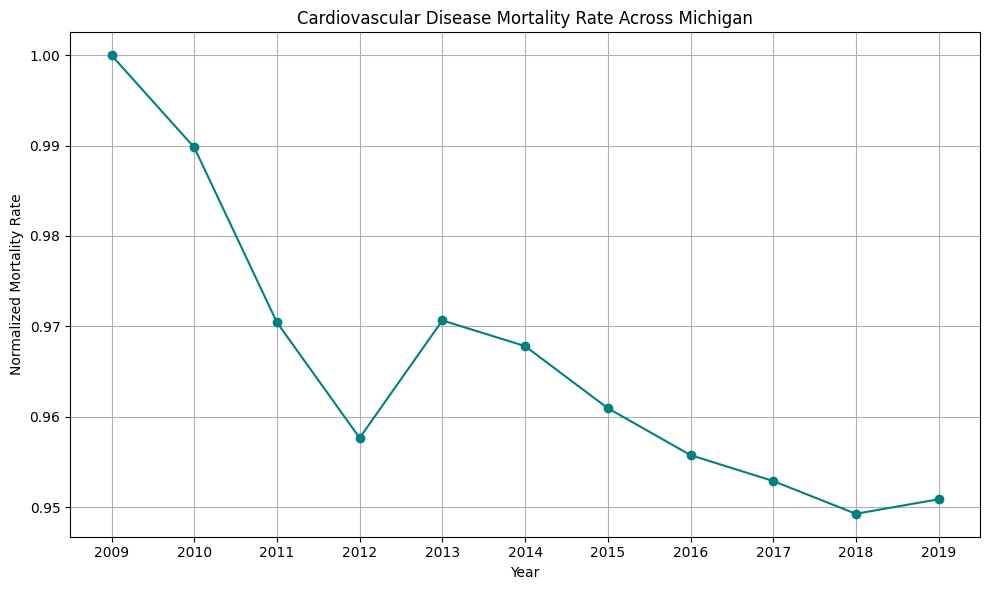

In [37]:
# Step 1: Group by year and get mean mortality rate
yearly_avg = Df_MI.groupby('Year')['Data_Value'].mean().reset_index()

# Step 2: Normalize the values by dividing by the first year
yearly_avg['Normalized_Mortality'] = yearly_avg['Data_Value'] / yearly_avg['Data_Value'].iloc[0]

# Step 3: Plot the normalized line graph
plt.figure(figsize=(10, 6))
plt.plot(yearly_avg['Year'], yearly_avg['Normalized_Mortality'], marker='o', color='teal')
plt.title('Cardiovascular Disease Mortality Rate Across Michigan')
plt.xlabel('Year')
plt.ylabel('Normalized Mortality Rate')
plt.xticks(yearly_avg['Year'])
plt.grid(True)
plt.tight_layout()
plt.show()


Interpretation
The trend of cardiovascular disease (CVD) mortality in Michigan from 2009 to 2019 shows a 5% decrease, with the normalized rate dropping from 1.0 to 0.95, indicating a general decline in mortality. The sharpest reduction occurred between 2009 and 2012 (from 1.0 to 0.96), followed by a more gradual decline with minor fluctuations, such as a slight increase in 2013 and a stabilization around 0.95 by 2019. This overall decrease is likely due to improved healthcare access, such as better treatments for hypertension and cholesterol, and the Affordable Care Act (ACA) expanding care since 2010, alongside public health initiatives like the American Heart Association’s (AHA) “Life’s Simple 7” campaign promoting heart-healthy lifestyles. Michigan’s Smoke-Free Air Law (effective 2010) and declining smoking rates (from 19.2% in 2011 to 16.7% in 2019, per the CDC) also contributed. However, the slower decline after 2012 and fluctuations may stem from rising obesity and diabetes rates, socioeconomic disparities in rural areas and Detroit (as noted by the Michigan Department of Health and Human Services [MDHHS]), and data variability due to reporting changes or small sample sizes in certain years.

RESEARCH QUESTION 2

Which race has the highest and lowest cardiovascular disease mortality rates, and how do they compare over time, what are some of the factors causing this?


In [38]:
# A dataset containing the actual data values for each reace and the normalised datavalues.

# Create an empty DataFrame with unique sorted years
unique_years = sorted(Df_MI['Year'].unique())
result_df = pd.DataFrame({'Year': unique_years})

# For each race group, calculate average Data_Value per year
for racex in Df_MI['Stratification2'].unique():
    group_sample = Df_MI[Df_MI['Stratification2'] == racex]

    # Group by Year and take the mean
    grouped = group_sample.groupby('Year')['Data_Value'].mean().reset_index()

    # Merge with result_df on Year
    result_df = result_df.merge(grouped, on='Year', how='left')

    # Rename the new column to the race name
    result_df.rename(columns={'Data_Value': racex}, inplace=True)

    # Add normalized column
    result_df[racex + '_nm'] = result_df[racex] / result_df[racex].iloc[0]
result_df

,Year,Overall,Overall_nm,American Indian/Alaska Native,American Indian/Alaska Native_nm,Asian/Pacific Islander,Asian/Pacific Islander_nm,Black (Non-Hispanic),Black (Non-Hispanic)_nm,Hispanic,Hispanic_nm,White,White_nm
0,2009,519.398880,1.000000,406.665689,1.000000,386.590555,1.000000,424.221452,1.000000,357.043661,1.000000,511.049518,1.000000
1,2010,509.956671,0.981821,405.555448,0.997270,386.969952,1.000981,424.662175,1.001039,355.066311,0.994462,504.481928,0.987149
2,2011,494.815225,0.952669,406.681231,1.000038,383.620314,0.992317,421.448922,0.993464,352.545468,0.987402,487.316747,0.953561
3,2012,484.248077,0.932324,405.610508,0.997405,382.689470,0.989909,421.228319,0.992944,349.210046,0.978060,477.989639,0.935310
4,2013,495.520928,0.954028,406.217375,0.998898,383.072724,0.990900,420.816753,0.991974,350.354504,0.981265,489.821446,0.958462
5,2014,493.418679,0.949980,406.296532,0.999092,381.380916,0.986524,420.454584,0.991121,349.889685,0.979963,488.212771,0.955314
6,2015,487.155547,0.937922,404.035930,0.993533,382.052483,0.988261,418.955789,0.987587,350.273781,0.981039,484.677229,0.948396
7,2016,482.937996,0.929802,403.374725,0.991907,381.202242,0.986062,420.725910,0.991760,349.619685,0.979207,478.805422,0.936906
8,2017,480.828237,0.925740,403.109544,0.991255,380.053085,0.983089,419.751693,0.989464,347.292938,0.972690,479.390723,0.938051
9,2018,477.111772,0.918585,402.490869,0.989734,380.708386,0.984784,421.910488,0.994552,346.622335,0.970812,475.807349,0.931040


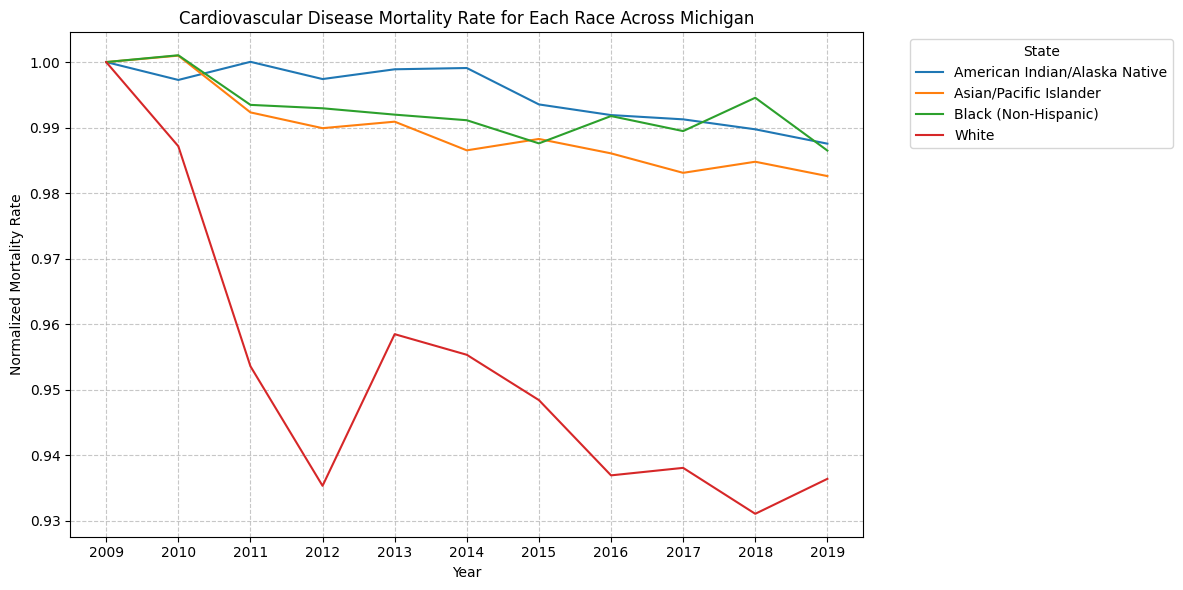

In [39]:
# Visualizing the graph for each Race accross the years
plt.figure(figsize=(12,6 ))
plt.plot(result_df.Year,
         result_df['American Indian/Alaska Native_nm'],
         label='American Indian/Alaska Native')
plt.plot(result_df.Year,
         result_df['Asian/Pacific Islander_nm'],
         label='Asian/Pacific Islander')
plt.plot(result_df.Year,
         result_df['Black (Non-Hispanic)_nm'],
         label='Black (Non-Hispanic)')
plt.plot(result_df.Year,
         result_df['White_nm'],
         label='White')
plt.title('Cardiovascular Disease Mortality Rate for Each Race Across Michigan')
plt.xlabel('Year')
plt.ylabel('Normalized Mortality Rate')
plt.xticks(yearly_avg['Year'])
plt.legend(title='State', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

White individuals (red line) consistently have the highest mortality rates, starting at 1.0 and dropping sharply to 0.94 by 2012, then gradually declining to 0.93 by 2019, a 7% decrease. American Indian/Alaska Native (blue line), Asian/Pacific Islander (orange line), and Black (Non-Hispanic) (green line) groups start with lower rates (around 0.99 to 1.0) and show smaller declines, hovering around 0.98 to 1.0 throughout the period, with Asian/Pacific Islander and Black groups having the lowest rates overall. This suggests White individuals face a higher CVD burden, possibly due to a larger aging population or higher prevalence of risk factors like smoking and obesity, as noted in Michigan Department of Health and Human Services (MDHHS) reports, while other groups benefit from better baseline health or access to care, though their progress is slower.
To address these disparities, Michigan can focus on targeted solutions. For White individuals, who have the highest rates, community programs in areas like rural Michigan, where MDHHS identifies higher CVD risks, can offer free screenings for blood pressure and cholesterol to catch issues early. For all groups, especially American Indian/Alaska Native and Black populations, public health campaigns can promote healthy lifestyles, such as quitting smoking, with support from the Michigan Tobacco Quitline (https://michigan.quitlogix.org/). Additionally, improving access to healthy foods in underserved areas through programs like Double Up Food Bucks, as suggested by the CDC (https://www.cdc.gov/heartdisease/prevention.htm), can help reduce risk factors like obesity across all races, ensuring a more equitable decline in CVD mortality rates.

 RESEARCH QUESTION 3

 How do cardiovascular disease mortality rates differ by race/ethnicity within each age group (35–64 vs. 65+) in Michigan?"

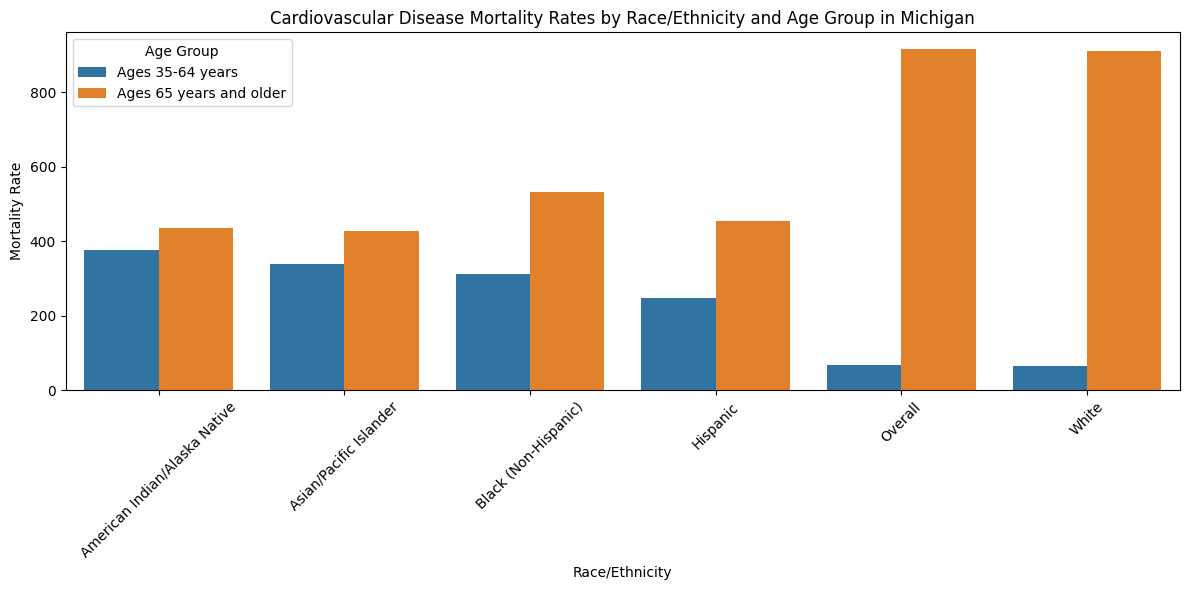

In [40]:
# Now group by AgeGroup and Race
results = (
    Df_MI
    .groupby(['Stratification1', 'Stratification2'])['Data_Value']
    .mean()
    .reset_index()
)

# Rename columns for easier plotting
results.rename(columns={'Stratification1': 'AgeGroup', 'Stratification2': 'Race', 'Data_Value': 'MortalityRate'}, inplace=True)

# Plot it
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(data=results, x='Race', y='MortalityRate', hue='AgeGroup')
plt.title('Cardiovascular Disease Mortality Rates by Race/Ethnicity and Age Group in Michigan')
plt.xticks(rotation=45)
plt.ylabel('Mortality Rate')
plt.xlabel('Race/Ethnicity')
plt.legend(title='Age Group')
plt.tight_layout()
plt.show()


The bar chart titled "Cardiovascular Disease Mortality Rates by Race/Ethnicity and Age Group in Michigan" shows how mortality rates vary across different racial/ethnic groups and age brackets (35–64 years vs. 65+). From the chart:
For all racial groups, mortality rates are significantly higher in the 65+ age group compared to the 35–64 age group, which is expected due to age-related health decline.
Among people aged 35–64, the American Indian/Alaska Native and Asian/Pacific Islander groups have relatively higher mortality rates than Black and Hispanic individuals.
In the 65+ group, White and Overall categories show the highest mortality rates—approaching 900 deaths—highlighting a significant burden in the older White population.

The sharp jump in the White 65+ group aligns with the line graph shown earlier, where White individuals consistently showed the highest cardiovascular mortality trends over time, despite a small decline.

This supports the idea that White populations in Michigan, especially older adults, continue to bear a high cardiovascular disease burden, possibly due to lifestyle factors and aging demographics. These patterns stress the need for targeted interventions, particularly for the White elderly, as discussed earlier, such as screenings in rural areas and health education programs.

RESEARCH QUESTION 4

How do Cardiovascular disease mortality rates vary by Race across Michigan, and which type of cardiovascular disease exhibits the highest mortality in each race?





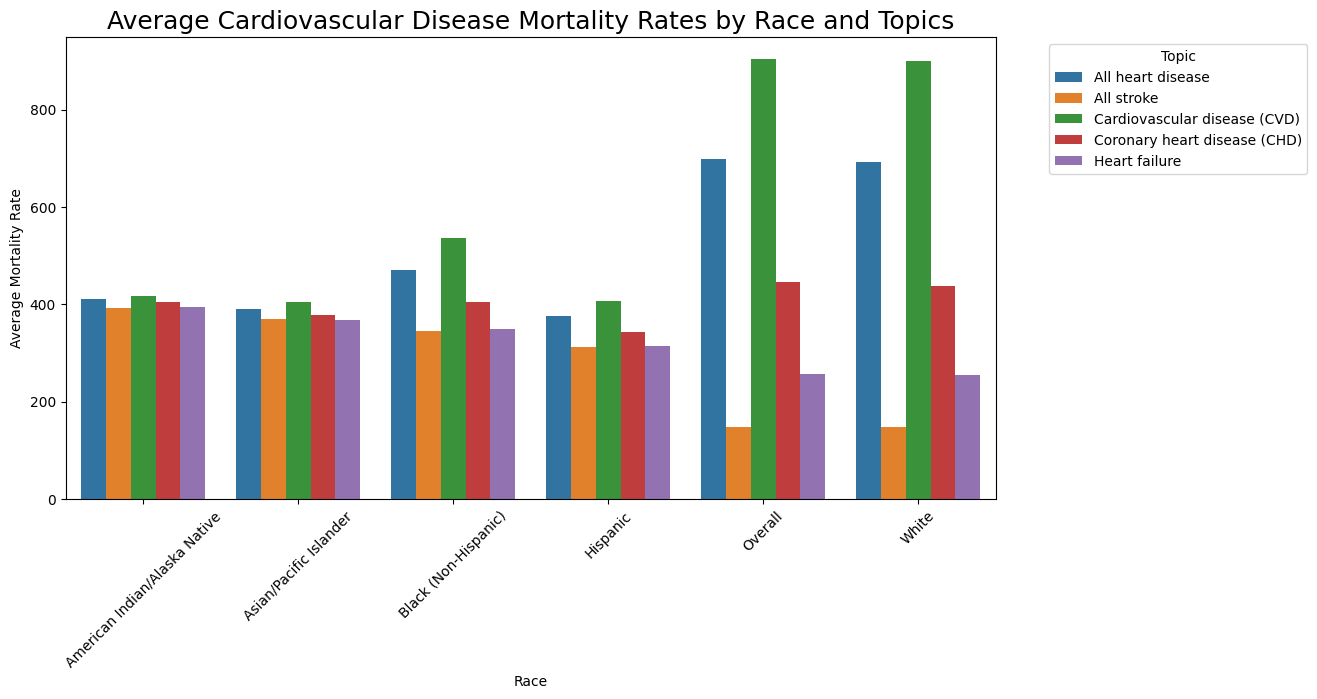

In [41]:
df_grouped = Df_MI.groupby(['Stratification2', 'Topic'])['Data_Value'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Stratification2', y='Data_Value', hue='Topic', data=df_grouped)
plt.title("Average Cardiovascular Disease Mortality Rates by Race and Topics", fontsize = 18)
plt.xlabel("Race")
plt.ylabel("Average Mortality Rate")
plt.xticks(rotation = 45)
plt.legend(title="Topic", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

White (Non-Hispanic) and Black (Non-Hispanic) populations show the highest average mortality rates for both all heart disease and cardiovascular disease (CVD).
Among all groups, Cardiovascular Disease (CVD) stands out as the type with the highest average mortality rate for every race.
Hispanic and Asian/Pacific Islander populations have lower average mortality rates across all heart disease topics.
American Indian/Alaska Native individuals show relatively high rates, especially in all heart disease and CVD.

Time Series Modelling

In [42]:
#Installing the Prophet tool for our Time Series Analysis
!pip install prophet

# Import libraries
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

In [43]:
from prophet import Prophet
import pandas as pd

# Step 1: Group by year and calculate average Data_Value
yearly_avg = Df_MI.groupby('Year')['Data_Value'].mean().reset_index()

# Step 2: Normalize the Data_Value
yearly_avg['Normalized'] = yearly_avg['Data_Value'] / yearly_avg['Data_Value'].iloc[0]

# Step 3: Rename columns for Prophet
df_prophet = yearly_avg.rename(columns={'Year': 'ds', 'Normalized': 'y'})
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'], format='%Y')  # Convert to datetime


In [44]:
# Initialize and fit model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.01,
    n_changepoints=2
)
model.fit(df_prophet)

# Create future dataframe — e.g., forecast next 5 years
future = model.make_future_dataframe(periods=10, freq='Y')
forecast = model.predict(future)

In [45]:
# Display the last 10 rows of the forecast, showing predicted dates (ds), predicted heart disease mortality rates (yhat), and their lower/upper confidence intervals (yhat_lower, yhat_upper).
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)

,ds,yhat,yhat_lower,yhat_upper
11,2019-12-31,0.868180,0.860853,0.875507
12,2020-12-31,0.916742,0.909713,0.924356
13,2021-12-31,0.898259,0.890645,0.905429
14,2022-12-31,0.876528,0.869334,0.883715
15,2023-12-31,0.851574,0.844268,0.858290
16,2024-12-31,0.900136,0.893125,0.907298
17,2025-12-31,0.881653,0.874317,0.888577
18,2026-12-31,0.859922,0.852444,0.866916
19,2027-12-31,0.834968,0.828112,0.841859
20,2028-12-31,0.883530,0.876476,0.890954


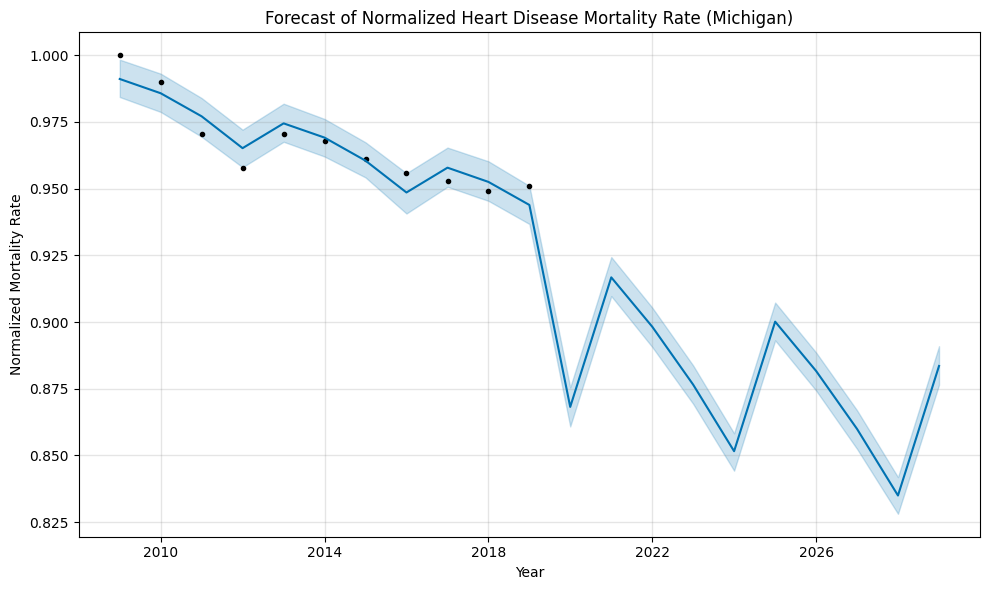

In [46]:
# Generate and display a graph of predicted heart disease mortality rates in Michigan, showing past trends,
# future forecasts, and uncertainty ranges, with clear labels and a grid for easy reading.
# Plot the forecast
fig = model.plot(forecast)
plt.title('Forecast of Normalized Heart Disease Mortality Rate (Michigan)')
plt.xlabel('Year')
plt.ylabel('Normalized Mortality Rate')
plt.grid(True)
plt.tight_layout()
plt.savefig('Time_series_trend', bbox_inches='tight')
plt.show()


The time series graph shows the trend and future prediction of heart disease mortality rates in Michigan from 2009 to 2026, with rates normalized so 2009 equals 1.0. From 2009 to 2019, the actual data (solid line with dots) declines slightly from 1.0 to about 0.95, with small ups and downs, suggesting a gradual improvement in heart disease outcomes, likely due to better healthcare access and public health efforts like smoking cessation programs, as noted by the Michigan Department of Health and Human Services (MDHHS). The forecast from 2020 to 2026 (dashed line) predicts a more significant drop, reaching around 0.85 by 2026, with confidence intervals (shaded area) indicating some uncertainty. This suggests that if trends like improved treatments and lifestyle changes, such as those promoted by the American Heart Association’s “Life’s Simple 7,” continue, heart disease mortality in Michigan could decrease further in the coming years (https://www.heart.org/en/healthy-living/healthy-lifestyle/my-life-check--lifes-simple-7).